# Multihazard Risk Screening of Rural Schools, Part 3: Interpretability

Accuracy alone does not justify trusting a screening model. This notebook
opens the four deployed classifiers with SHAP and asks whether the drivers of
their predictions match structural engineering judgment.

SHAP assigns every attribute of every prediction a signed contribution with a
game theoretic guarantee: contributions add up exactly to the difference
between the prediction and the average prediction. Aggregating absolute
contributions over the holdout gives a faithful global ranking of what each
model actually uses.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "schoolrisk").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import pandas as pd

from schoolrisk.config import HAZARDS
from schoolrisk.data import load_dataset, split_dataset
from schoolrisk.explain import beeswarm_figure, contribution_figure, explain_hazard
from schoolrisk.modeling import load_card, load_model
from schoolrisk.plots import apply_style, save_figure

apply_style()

models = {hazard: load_model(hazard) for hazard in HAZARDS}
cards = {hazard: load_card(hazard) for hazard in HAZARDS}
pd.DataFrame(
    [
        {
            "Hazard": HAZARDS[h].display,
            "Deployed model": cards[h]["model"],
            "Holdout macro F1": round(cards[h]["holdout_metrics"]["f1_macro"], 4),
        }
        for h in HAZARDS
    ]
)

,Hazard,Deployed model,Holdout macro F1
0,Earthquake,LightGBM,0.9619
1,Landslide,LightGBM,0.8329
2,Flood,LightGBM,0.9804
3,Windstorm,Extra trees,0.9124


SHAP values are computed on the same holdout partition used for the audit, so
the explanations describe behavior on data the models never fit.

In [3]:
bundles = {}
for hazard in HAZARDS:
    df = load_dataset(hazard)
    _, X_test, _, _ = split_dataset(df)
    bundles[hazard] = explain_hazard(models[hazard], X_test, hazard)

## 1. What drives each hazard

Each bar is one attribute's share of the model's total decision signal,
split by risk class. The stacks answer two questions at once: which
attributes matter, and whether an attribute speaks mostly for one class or
for all three.

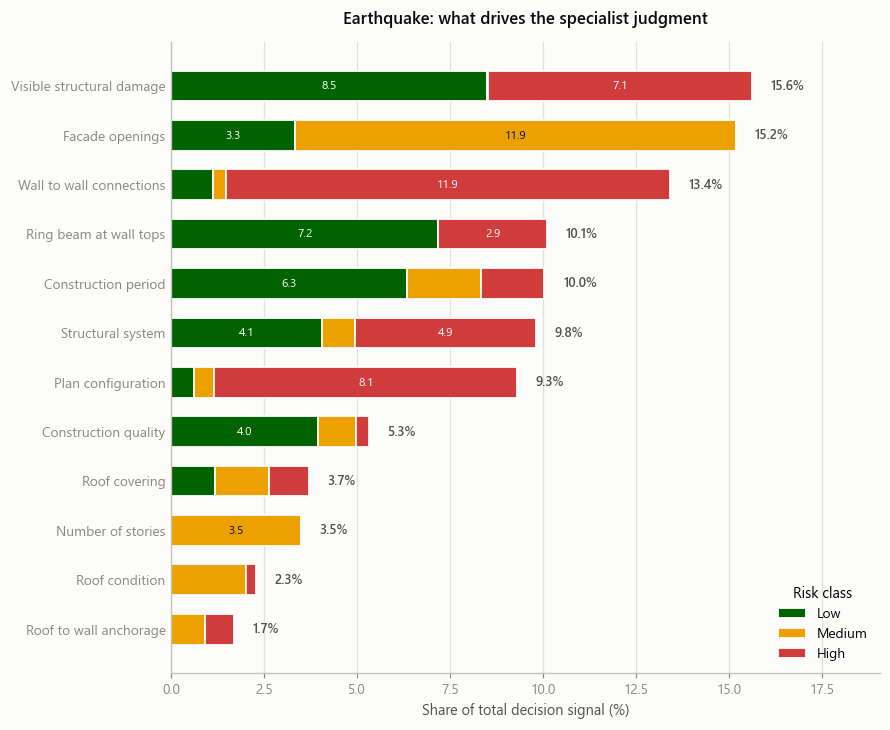

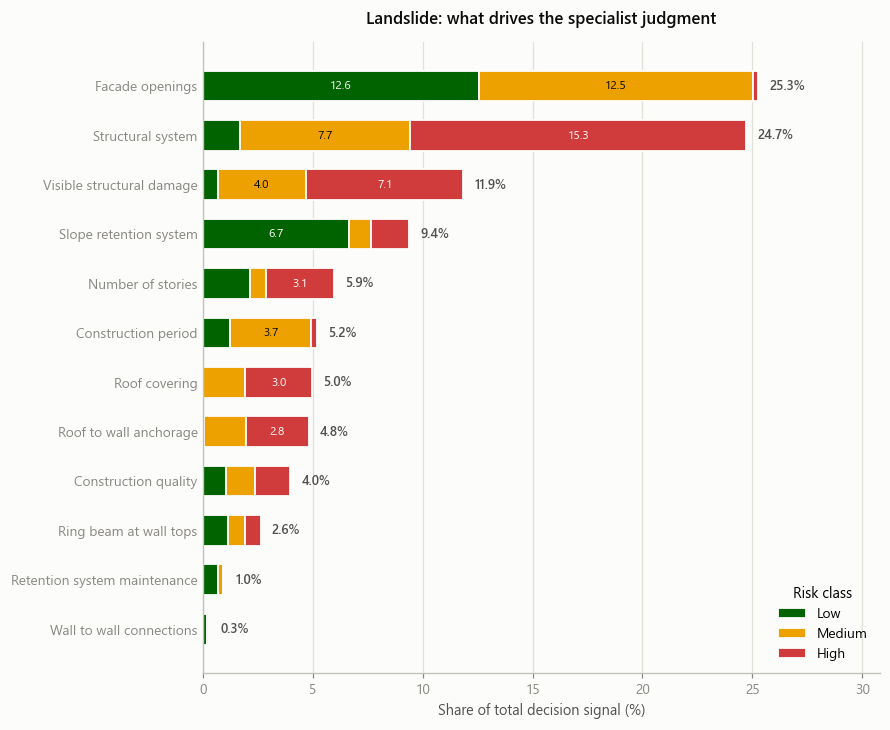

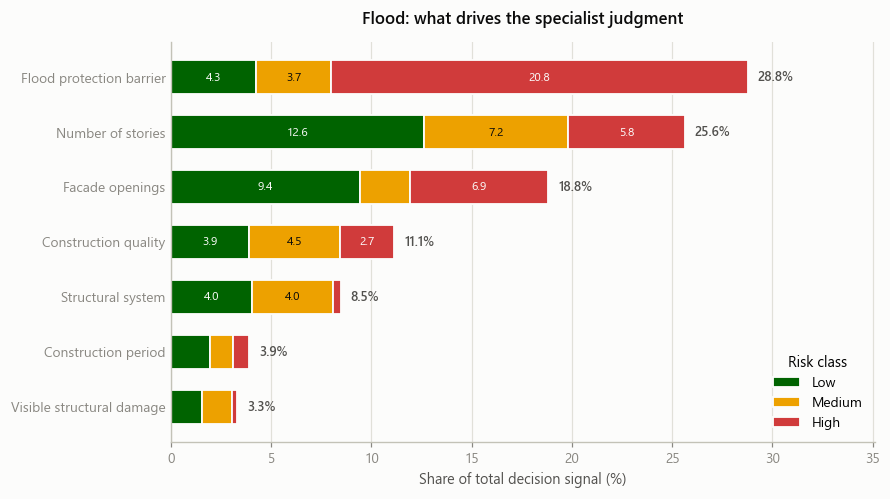

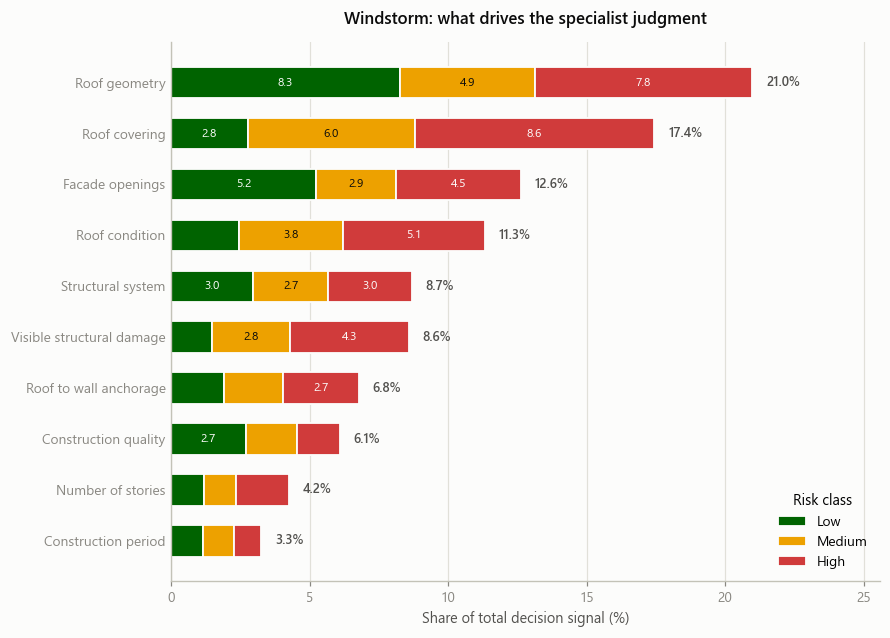

In [4]:
for hazard in HAZARDS:
    fig = contribution_figure(bundles[hazard]["table"], hazard)
    save_figure(fig, f"shap_{hazard}")

## 2. Per building contributions

The beeswarm shows every holdout building as one point per attribute, for the
High risk output. Position is the signed contribution; color is the encoded
severity of the attribute in that building. A clean severity gradient from
left to right means the model uses the attribute monotonically, exactly what
an expert criterion should look like.

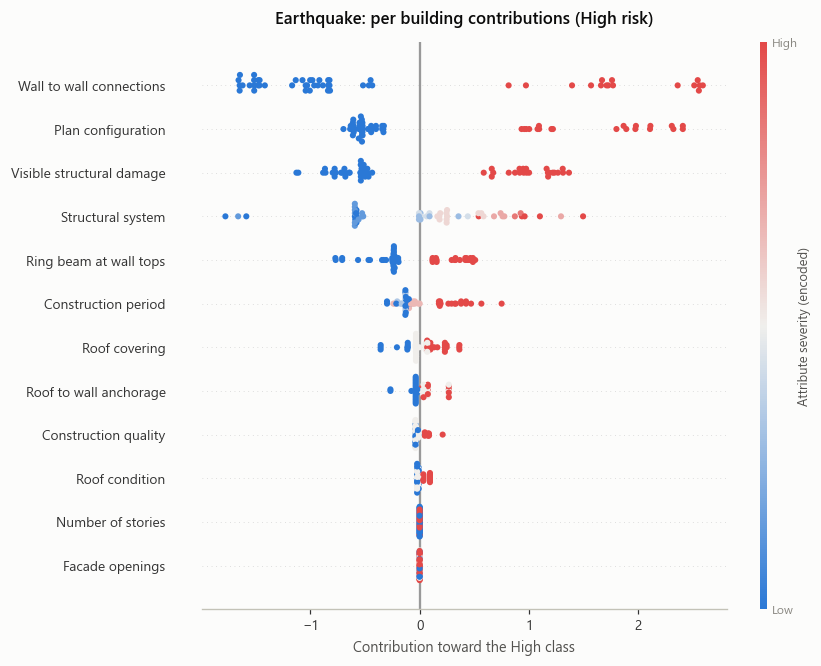

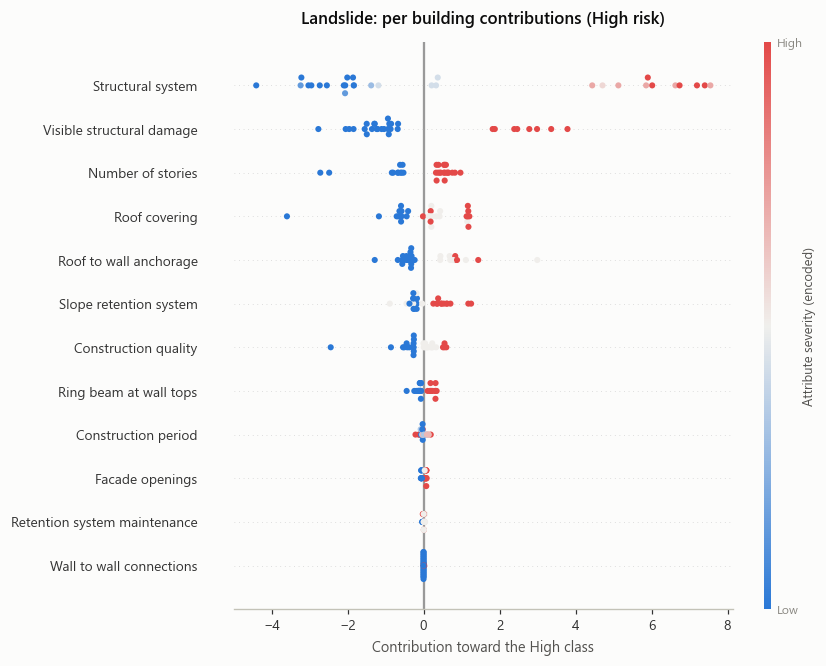

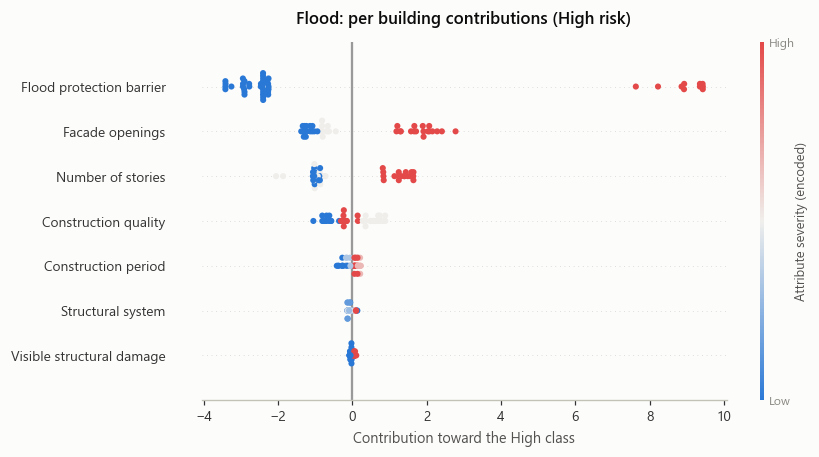

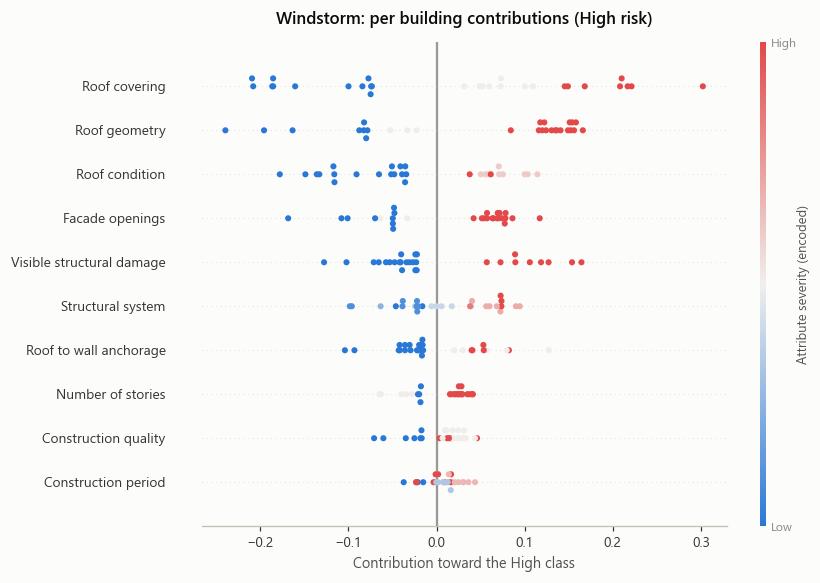

In [5]:
for hazard in HAZARDS:
    fig = beeswarm_figure(bundles[hazard], hazard)

## 3. The same attributes across hazards

Sharing one vocabulary across the four models allows a direct comparison:
each column is one hazard, each cell the attribute's share of that model's
decision signal.

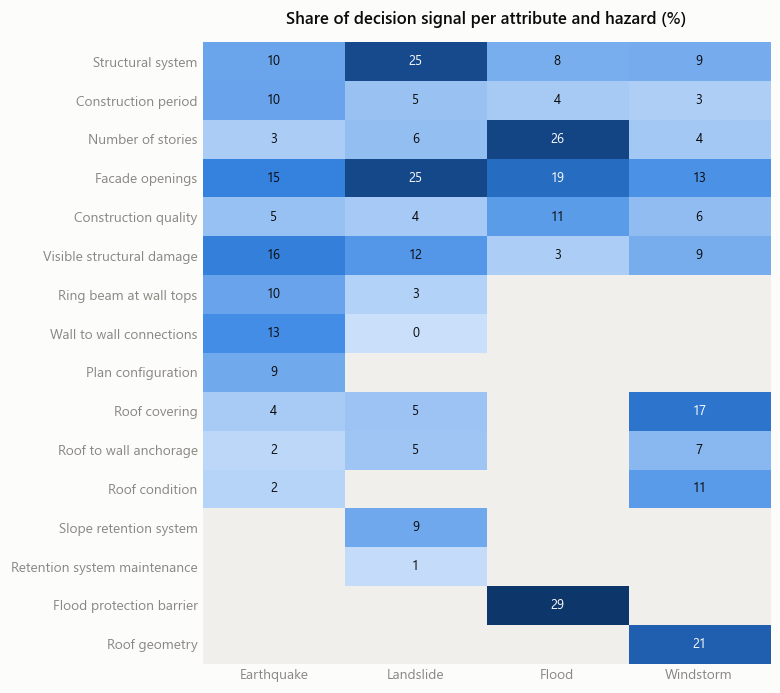

In [6]:
import matplotlib.pyplot as plt
import numpy as np

from schoolrisk.plots import SEQ_CMAP, INK, SURFACE

order = []
for hazard in HAZARDS:
    for feature in HAZARDS[hazard].feature_names:
        if feature not in order:
            order.append(feature)

matrix = pd.DataFrame(index=order, columns=list(HAZARDS), dtype=float)
for hazard in HAZARDS:
    totals = bundles[hazard]["table"]["Total"]
    for feature in HAZARDS[hazard].feature_names:
        matrix.loc[feature, hazard] = totals.get(feature, 0.0)

from schoolrisk.config import FEATURE_DISPLAY

display_names = [FEATURE_DISPLAY.get(f, f) for f in matrix.index]

fig, ax = plt.subplots(figsize=(7.2, 6.4))
values = matrix.values.astype(float)
masked = np.ma.masked_invalid(values)
cmap = SEQ_CMAP.copy()
cmap.set_bad("#f0efec")
ax.imshow(masked, cmap=cmap, vmin=0, aspect="auto")
ax.set_xticks(range(len(matrix.columns)),
              [HAZARDS[h].display for h in matrix.columns], fontsize=9)
ax.set_yticks(range(len(matrix.index)), display_names, fontsize=9)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = values[i, j]
        if np.isnan(value):
            continue
        color = SURFACE if value > np.nanmax(values) * 0.55 else INK
        ax.text(j, i, f"{value:.0f}", ha="center", va="center",
                fontsize=8.5, color=color)
ax.set_title("Share of decision signal per attribute and hazard (%)", pad=12)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
_ = save_figure(fig, "shap_cross_hazard")

Gray cells mark attributes that are not part of that hazard's survey.

## Engineering reading

The rankings align with how each failure mechanism works, which is the
strongest evidence that the models learned the expert criteria rather than
dataset artifacts.

* **Earthquake.** The signal concentrates in the integrity of the lateral
  load path: visible damage, wall to wall connections, facade openings and
  the ring beam. Roof attributes stay marginal, as expected for ground
  shaking.
* **Landslide.** Configuration and site combine: facade openings and the
  structural system dominate, with visible damage and the slope retention
  system completing the leading group.
* **Flood.** A short hierarchy dominated by the flood barrier and by vertical
  exposure through the number of stories and the openings. Age hardly
  matters, and none of the roof attributes even belong to this survey.
* **Windstorm.** The envelope rules: roof geometry, roof covering and roof
  condition carry about half of the signal, with facade openings adding
  suction paths. Structural age is nearly irrelevant.

For prioritizing retrofits, the levers differ per hazard: connections and
ring beams for earthquake, slope retention for landslide, barriers for
flood, roof configuration for windstorm. The final notebook quantifies
exactly that.